In [2]:
#Experiment 2


In [4]:
#step 1: Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error,r2_score


In [6]:
#Load Auto MPG dataset
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

#display first five rows

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [8]:
#Separate input and output

X=df[['displacement']]
y=df['mpg']
#check missing values
print("Missing values in:",X.isnull().sum())
print("Missing values in mpg:",y.isnull().sum())


Missing values in: displacement    0
dtype: int64
Missing values in mpg: 0


In [10]:
#Remove rows containing mising values
data = df[['displacement','mpg']].dropna()

#update input and output
X= data[['displacement']]
y=data[['mpg']]

#Dispaly the selecte data
print("Features:")
print (X.head())

print("\nTarget:")
print(y.head())

Features:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target:
    mpg
0  18.0
1  15.0
2  18.0
3  16.0
4  17.0


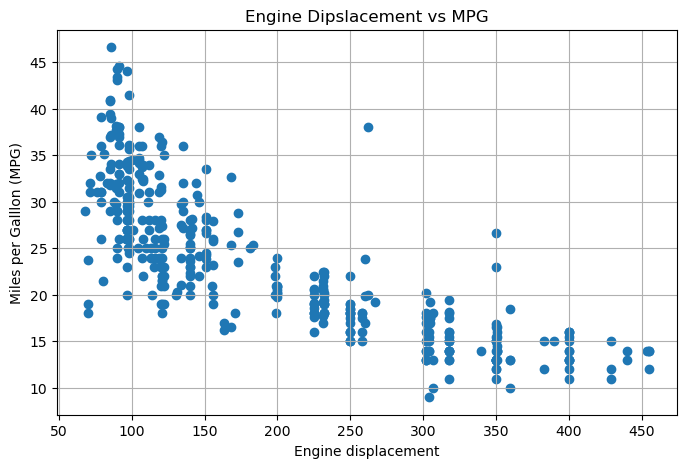

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(X,y)

plt.xlabel("Engine displacement")
plt.ylabel("Miles per Galllon (MPG)")
plt.title("Engine Dipslacement vs MPG")

plt.grid(True)
plt.show()

In [14]:
#Split the dataset
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:",len(X_train))
print("Testing samples:",len(X_test))

Training samples: 318
Testing samples: 80


In [15]:
#create Linear Regression model
linear_model = LinearRegression()

#train model
linear_model.fit(X_train,y_train)

#predict on test data
y_pred_linear = linear_model.predict(X_test)

In [16]:
#calculate MSE
mse_linear = mean_squared_error(y_test,y_pred_linear)

#Calculate R-squared

r2_linear = r2_score(y_test,y_pred_linear)


print("Linear Regression Results")
print("---------------")
print("MSE",mse_linear)
print("R-squared:",r2_linear)

Linear Regression Results
---------------
MSE 18.102543998358946
R-squared: 0.6633114869465595


In [19]:
#Store results
results = []
#store polynomial models for plotting

polynomial_models={}

#add linear regression results

results.append({
    'Model':'Linear Regression',
    'Degree':1,
    'MSE':mse_linear,
    'R-squared':r2_linear
})

#Try polynomila degress from 2 to 5
for degree in range (2,6):
    #create polynomial features
    # Correct
    poly = PolynomialFeatures(degree=degree)

    #transfrom training and testing data
    X_train_poly =poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    #create Linear Regression model
    poly_model = LinearRegression()

    #Train polynomial regression model
    poly_model.fit(X_train_poly,y_train)

    #make predictions

    y_pred_poly = poly_model.predict(X_test_poly)

    #Calculate evaluation metrics 

    mse = mean_squared_error(y_test,y_pred_poly)

    r2 = r2_score(y_test,y_pred_poly)

    #store results

    results.append({
        'Model':'Polynomial Regression',

        'Degree': degree,

        'MSE':mse,

        'R-squared':r2
    })

    #store model and polynomial transformer


    polynomial_models[degree] ={
        'poly':poly,

        'model':poly_model }


    
















In [20]:
#Convert results into  DataFrame

results_df = pd.DataFrame(results)

#display results

results_df

,Model,Degree,MSE,R-squared
0,Linear Regression,1,18.102544,0.663311
1,Polynomial Regression,2,15.107354,0.719019
2,Polynomial Regression,3,14.943632,0.722064
3,Polynomial Regression,4,14.961487,0.721732
4,Polynomial Regression,5,15.230896,0.716721


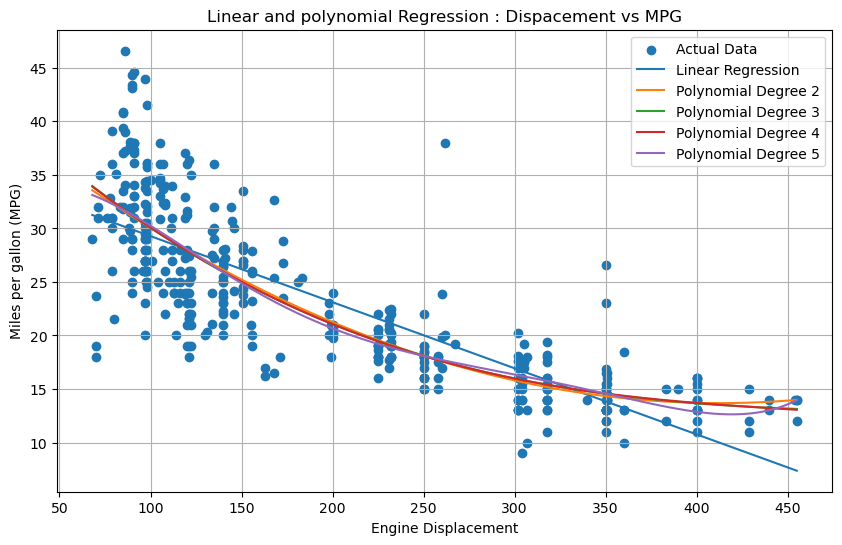

In [22]:
# Create smooth X values fro plotting
X_plot = pd.DataFrame({
    'displacement':np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),
        300)
})

#create figure 

plt.figure(figsize=(10,6))

#plot actual data


plt.scatter (
    X['displacement'],
    y,
    label='Actual Data'

)

#--------------------
y_plot_linear= linear_model.predict(X_plot)

plt.plot(
    X_plot['displacement'],
    y_plot_linear,
    label='Linear Regression',

)
#-------------------------------


for degree in range (2,6):

    #Retrieve stored transformer and model 

    poly = polynomial_models[degree]['poly']
    poly_model = polynomial_models[degree]['model']

    #Transform smooth X values 

    X_plot_poly = poly.transform(X_plot)

    #Predicts 

    y_plot_poly = poly_model.predict(X_plot_poly)

    #plot curve

    plt.plot(

        X_plot['displacement'],
        y_plot_poly,

        label = f'Polynomial Degree {degree}'

    )

    #plot fromatting

plt.xlabel('Engine Displacement')
plt.ylabel('Miles per gallon (MPG)')

plt.title(
    'Linear and polynomial Regression : Dispacement vs MPG'
)

plt.legend()
plt.grid(True)
plt.show()





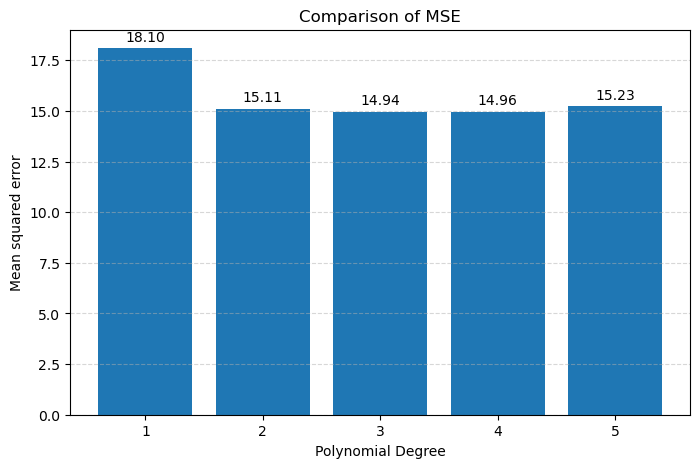

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
bars = plt.bar(
    results_df['Degree'].astype(str),
    results_df['MSE']
)
#add labels above bars
plt.bar_label(bars,fmt='%.2f',padding=3)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean squared error")
plt.title("Comparison of MSE")
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

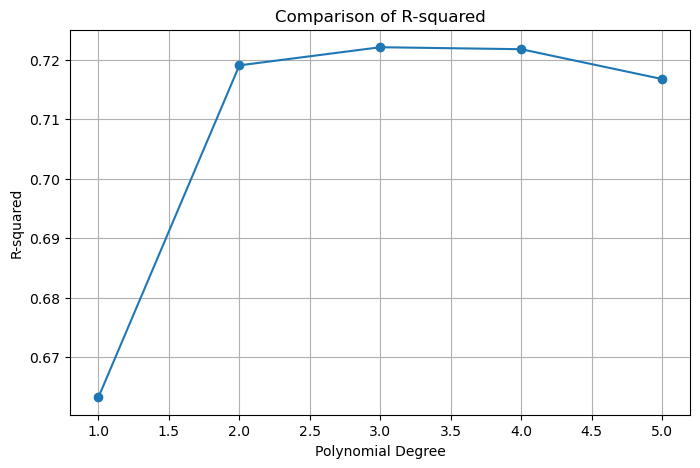

In [31]:
plt.figure (figsize=(8,5))

plt.plot(
    results_df['Degree'],
    results_df['R-squared'],
    marker='o'
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R-squared")
plt.title("Comparison of R-squared")

plt.grid(True)

plt.show()

